## Storing and Accessing Your API Key in Colab

To securely store your API key in Google Colab, follow these steps:

1.  **Open Secrets Manager**: Click on the "🔑" icon (padlock icon) in the left sidebar of your Colab notebook. This will open the "Secrets" panel.
2.  **Add a New Secret**: Click on "+ New secret".
3.  **Name Your Secret**: In the "Name" field, type a descriptive name for your API key, for example, `GOOGLE_API_KEY`.
4.  **Enter Your API Key**: In the "Value" field, paste your actual API key.
5.  **Save Secret**: Click "Save secret".
6.  **Enable Notebook Access**: Make sure the toggle next to your secret (e.g., `GOOGLE_API_KEY`) is turned **on** for this notebook. This allows your notebook to access the secret.

Once stored, you can access your API key in your code as shown in the cell below:

In [ ]:
# Import the userdata module from google.colab
from google.colab import userdata

# Access your API key using the name you gave it in the Secrets Manager
# Replace 'GOOGLE_API_KEY' with the actual name you used if it's different.
api_key = userdata.get('GOOGLE_API_KEY')

# You can print a part of it to confirm it's loaded, but be careful not to expose the full key.
# For example, print the first few characters or a confirmation message.
print(f"API Key loaded successfully (starts with: {api_key[:5]}...)")

# You can then use this 'api_key' variable in your code where the API key is required.
# For example, if you're configuring a service:
# genai.configure(api_key=api_key)

API Key loaded successfully (starts with: AQ.Ab...)


In [ ]:
!pip install langchain-google-genai
!pip install google-generativeai
!pip install langchain-community
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.3/346.3 kB 10.1 MB/s eta 0:00:00


In [ ]:
from langchain_google_genai import (
    ChatGoogleGenerativeAI,
    GoogleGenerativeAIEmbeddings
)

In [ ]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

from langchain_community.tools.tavily_search import TavilySearchResults
load_dotenv()

/tmp/ipykernel_1317/3289519596.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


False

In [ ]:
docs = (
    PyPDFLoader("/content/book1.pdf").load()
    + PyPDFLoader("/content/book2.pdf").load()
    + PyPDFLoader("/content/book3.pdf").load()
)

In [ ]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")


In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    api_key=api_key
)
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

GoogleGenerativeAIError: Error embedding content (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 100, model: gemini-embedding-1.0\nPlease retry in 23.758684627s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/embed_content_free_tier_requests', 'quotaId': 'EmbedContentRequestsPerMinutePerUserPerProjectPerModel-FreeTier', 

In [ ]:
!pip install langchain-huggingface
from langchain_huggingface import HuggingFaceEmbeddings


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 94.9 MB/s eta 0:00:00


In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
!pip install langchain-groq
from langchain_groq import ChatGroq
from google.colab import userdata

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    api_key=userdata.get("GROQ_API_KEY")
)

In [ ]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [ ]:
# -----------------------------
# State
# -----------------------------
class State(TypedDict):
    question: str

    docs: List[Document]
    good_docs: List[Document]

    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_query: str

    web_docs: List[Document]

    answer: str

In [ ]:
# -----------------------------
# Retrieve
# -----------------------------
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}


In [ ]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)


def eval_each_doc_node(state: State) -> State:
    q = state["question"]
    scores: List[float] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)

        # Keep any doc above LOWER_TH as "weakly relevant"
        if out.score > LOWER_TH:
            good.append(d)

    # CORRECT: at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # INCORRECT: all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }

    # AMBIGUOUS: otherwise
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }


In [ ]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter. Your task is to determine if a given sentence directly helps answer a question. Return a JSON object with a single key, 'keep', set to 'true' (boolean) if it helps, otherwise 'false' (boolean). Use ONLY the sentence provided. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# Knowledge refinement
# (CORRECT => internal only)
# (INCORRECT => web only)
# (AMBIGUOUS => internal + web)
# -----------------------------
def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:  # AMBIGUOUS
        docs_to_use = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [ ]:
# -----------------------------
# Query rewrite for web search
# -----------------------------
class WebQuery(BaseModel):
    query: str


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


def rewrite_query_node(state: State) -> State:
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}


# -----------------------------
# Web search node: uses web_query
# -----------------------------
tavily = TavilySearchResults(max_results=5, tavily_api_key=userdata.get("TAVILY_API_KEY"))


def web_search_node(state: State) -> State:
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    web_docs: List[Document] = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}

In [ ]:
# -----------------------------
# Generate
# -----------------------------
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "context": state["refined_context"]})
    return {"answer": out.content}


In [ ]:
# -----------------------------
# Routing
# CORRECT => refine
# INCORRECT / AMBIGUOUS => rewrite -> web_search -> refine -> generate
# -----------------------------
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"


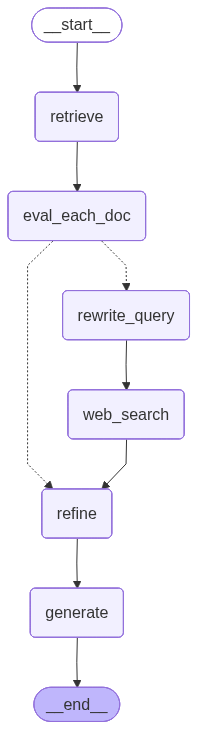

In [ ]:
# -----------------------------
# Build graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

# non-correct path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")

# correct path already goes to refine
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app


In [ ]:
# -----------------------------
# Run example
# -----------------------------
res = app.invoke(
    {
        "question": "Batch normalization vs layer normalization",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_query": "",
        "web_docs": [],
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("WEB_QUERY:", res["web_query"])
print("\nOUTPUT:\n", res["answer"])


VERDICT: AMBIGUOUS
REASON: No chunk scored > 0.7, but not all were < 0.3.
WEB_QUERY: batch normalization vs layer normalization

OUTPUT:
 Batch normalization and layer normalization are two techniques used to normalize the inputs to a neural network layer. 

Batch normalization normalizes the inputs across a mini-batch of data, whereas layer normalization normalizes the inputs across the features for each individual data point. 

Batch normalization is useful for stabilizing training dynamics and accelerating convergence, but it can be less effective with small batch sizes or fluctuating data distributions. 

Layer normalization, on the other hand, is more flexible and robust, especially in scenarios with small batch sizes or sequential models like RNNs, as it normalizes the activations of each input layer across the entire dataset. 

The choice between batch normalization and layer normalization depends on the specific characteristics of the dataset, the neural network architecture, a

In [ ]:
# Install Streamlit, sentence-transformers, tavily-python, and localtunnel (for exposing the app in Colab)
!pip install streamlit sentence-transformers tavily-python
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
changed 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [ ]:
import sentence_transformers

# Explicitly load the model to ensure it's downloaded and cached
# This creates a dummy SentenceTransformer instance which will download the model if not present.
_ = sentence_transformers.SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]